In [1]:
# Run this line if you want to restart the kenerl
from IPython.display import display, Javascript

display(Javascript('IPython.notebook.kernel.restart()'))

<IPython.core.display.Javascript object>

In [1]:
pip install ipywidgets

     ---------------------------------------- 0.0/139.4 kB ? eta -:--:--
     -------- ------------------------------ 30.7/139.4 kB 1.3 MB/s eta 0:00:01
     ------------------------------ ------- 112.6/139.4 kB 1.3 MB/s eta 0:00:01
     -------------------------------------- 139.4/139.4 kB 1.2 MB/s eta 0:00:00
     ---------------------------------------- 0.0/215.0 kB ? eta -:--:--
     -------------------- ------------------- 112.6/215.0 kB ? eta -:--:--
     -------------------------------------- 215.0/215.0 kB 3.3 MB/s eta 0:00:00
     ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
     ---- ----------------------------------- 0.2/2.3 MB 7.3 MB/s eta 0:00:01
     ---------- ----------------------------- 0.6/2.3 MB 6.6 MB/s eta 0:00:01
     ------------------ --------------------- 1.1/2.3 MB 7.6 MB/s eta 0:00:01
     ------------------- -------------------- 1.1/2.3 MB 7.8 MB/s eta 0:00:01
     ------------------------------ --------- 1.8/2.3 MB 7.4 MB/s eta 0:00:0

In [2]:
pip install lckr_jupyterlab_variableinspector

     ---------------------------------------- 0.0/156.4 kB ? eta -:--:--
     ------- ------------------------------- 30.7/156.4 kB 1.4 MB/s eta 0:00:01
     --------------------------- ---------- 112.6/156.4 kB 1.3 MB/s eta 0:00:01
     -------------------------------------- 156.4/156.4 kB 1.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [1]:
import tensorflow as tf
print(tf.__version__)

2.10.0


In [2]:
import numpy as np
import os
from PIL import Image

In [3]:
folder_path = 'IL033_teste_export_slice_tiff/'
# List all files in the folder
files = os.listdir(folder_path)

In [4]:
images = []
import cv2
# Save the image in the tensor to process
i = 0
for filename in files:
    if filename.endswith('.tiff') or filename.endswith('.tif'):
        i = i + 1
        file_path = os.path.join(folder_path, filename)
        image = cv2.imread(file_path)
        
        globals()[f'tensor_image_{i}'] = np.array(image)
        globals()[f'name_slice_{i}'] = filename
#        images.append(np.array(image))  # Convert the PIL Image to a NumPy array

In [5]:
# This function is to create a multi-class binary mask using Otsu's thresholding technique
def create_multi_class_binary(img):    
    import cv2
    # Convert the image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply Otsu's thresholding to segment different classes
    _, binary1 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, binary2 = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    # You can add more thresholds for additional classes as needed

    # Combine the binary masks to create a multi-class mask
    multi_class_mask = cv2.bitwise_or(binary1, binary2)
    # Combine additional masks if more classes are present
    
    return multi_class_mask

In [6]:
for j in range(1, 3122): # Quantidade de tensores imagens: 3121
    globals()[f'tensor_multi_class_binary_{j}'] = create_multi_class_binary(globals()[f'tensor_image_{j}'])


1


KeyError: 'tensor_image_1'

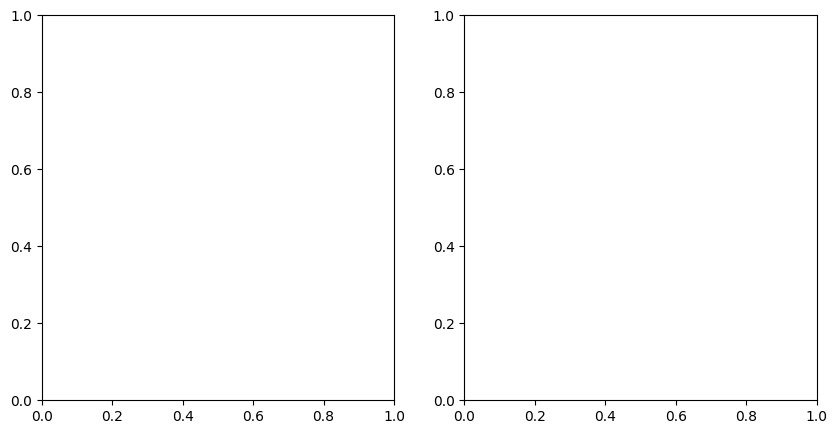

In [47]:
## Verificando se as imagens binárias são correspondentes com as imagens de entrada:
import random

# Define the range
min_value = 1
max_value = 3121

# Generate a random number between the range
random_number = random.randint(min_value, max_value)
random_number = 1
# Print the random number
print(random_number)
import matplotlib.pyplot as plt
import numpy as np

# Create two sample arrays


# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Plot the original image
axs[0].imshow(globals()[f'tensor_image_{random_number}'], cmap='gray')
axs[0].set_title('image')

# Plot the binary image
axs[1].imshow(globals()[f'tensor_multi_class_binary_{random_number}'], cmap='gray')
axs[1].set_title('binary image')

# Show the plot
plt.show()

In [8]:
## Test 2

In [3]:
import numpy as np
import os
from PIL import Image
import cv2
import tensorflow as tf
print(tf.__version__)

2.10.0


In [38]:
the_position = 2529 - 329 

In [39]:
the_position

2200

In [5]:
# Loading the images to the methodology
slice_0330_image = cv2.imread("slice2529.tif")

In [6]:
slice_0330_image.min(), slice_0330_image.max(), slice_0330_image.mean()

(24, 186, 97.04692333304692)

In [7]:
(slice_0330_image.min() - slice_0330_image.max())  + 0.5 * (slice_0330_image.min() - slice_0330_image.max())

C:\Users\CometLake_05\AppData\Local\Temp\ipykernel_20216\1973424946.py:1: RuntimeWarning: overflow encountered in ubyte_scalars
  (slice_0330_image.min() - slice_0330_image.max())  + 0.5 * (slice_0330_image.min() - slice_0330_image.max())


141.0

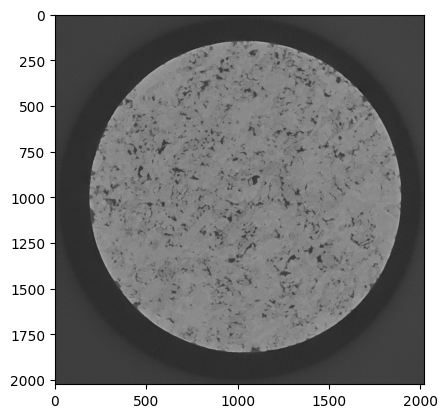

In [8]:
import matplotlib.pyplot as plt
# Plot the image 1
plt.figure()
plt.imshow(cv2.cvtColor(slice_0330_image, cv2.COLOR_BGR2RGB))
plt.show()

In [12]:
# Set the grain to be the value 1
# This function is to create the binary image to the recognition process work
def create_binary(img):    
    import cv2
    # Convert the image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Apply a threshold to the grayscale image
    #threshold_value = 95
    threshold_value = img.mean() + 0.20 * img.mean()
    print(threshold_value)
    #threshold_value = slice_0330_image.mean()
    max_value = 1
    # Set the value 1 to be the pore space
    ret, binary = cv2.threshold(gray, threshold_value, max_value, cv2.THRESH_BINARY)
    return binary

In [13]:
slice_0330_image.min(), slice_0330_image.max(), slice_0330_image.mean()

(24, 186, 97.04692333304692)

In [14]:
# with thresold
slice_0330_image_binary = create_binary(slice_0330_image)


116.4563079996563


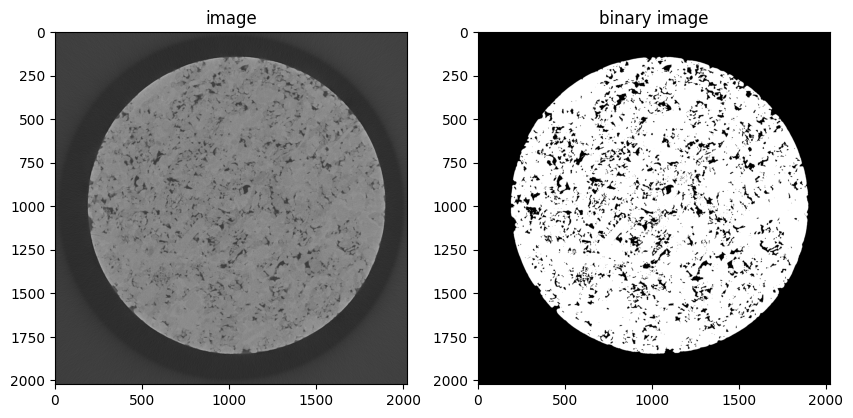

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Create two sample arrays


# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Plot the original image
axs[0].imshow(cv2.cvtColor(slice_0330_image, cv2.COLOR_BGR2RGB))
axs[0].set_title('image')

# Plot the binary image
axs[1].imshow(slice_0330_image_binary, cmap='gray')
axs[1].set_title('binary image')

# Show the plot
plt.show()

In [26]:
# BEGGIN FUNCTION SEGMENTATION WITH U NET
# Calling the function
def segmentation_with_u_net_sample_1(image_array, mask_array):
    # convert the image_array from uint8 to float64
    import numpy as np
    # convert to the numpy array
    image_array = np.array(image_array)
    mask_array = np.array(mask_array)
    # Remove the third dimension
    image_array = image_array[:, :, 0]
    # Convert uint8 to float64
    image_array = image_array.astype('float32')
    
    # convert the image_array from uint8 to float64
    import numpy as np

    # Convert uint8 to float32
    mask_array = mask_array.astype('float32')

    # calculate the range of the min and max value of the image_array
    range_image_array = image_array.max() - image_array.min()
    # normalize the image_array to segmentation task
    image_array = (image_array - image_array.min()) / (range_image_array)
    # The step is the size of the moviment in one direction by the patch.
     
    
    from skimage.util import view_as_windows
    #==================old version to create patches==================
    # create patches to the images (original and binary)
    # Split the image and mask arrays into patches
    ##patch_size = (256, 256)  # define the patch size
    ##image_patches = view_as_windows(image_array, patch_size, step=256) 
    ##mask_patches = view_as_windows(mask_array, patch_size, step=256)

    # Reshape the patches to flatten them into 2D arrays
    ##image_patches = image_patches.reshape(-1, *patch_size)
    ##mask_patches = mask_patches.reshape(-1, *patch_size)
    # Add the color channel to the patches
    # Add a color channel
    ##image_patches = np.expand_dims(image_patches, axis=3)
    ##mask_patches = np.expand_dims(mask_patches, axis=3)
    #================================================================
    #===================new version to creat patches=================
    ## New version - sucess
    ## If you normalize the original image, you need to convert to the original scale to reconstruct
    ## If you don't normalize the code works...
    import numpy as np
    from skimage.util import view_as_windows

    # Convert image_array from uint8 to float64
    ##image_array = np.array(image_array)[:, :, 0].astype('float32')

    # Convert mask_array from uint8 to boolean
    ##mask_array = np.array(mask_array).astype('bool')

    # Normalize the image_array
    #range_image_array = image_array.max() - image_array.min()
    #image_array = (image_array - image_array.min()) / (range_image_array)

    # Split the image and mask arrays into patches
    patch_size = (184, 184)
    step = 184
    image_patches = view_as_windows(image_array, patch_size, step=step)
    mask_patches = view_as_windows(mask_array, patch_size, step=step)

    # Reshape the patches to flatten them into 2D arrays
    image_patches_flat = image_patches.reshape(-1, *patch_size)
    mask_patches_flat = mask_patches.reshape(-1, *patch_size)

    # Add the color channel to the patches
    image_patches_flat = np.expand_dims(image_patches_flat, axis=3)
    mask_patches_flat = np.expand_dims(mask_patches_flat, axis=3)

    # Save the position of each patch
    patch_positions = []

    for i in range(image_patches.shape[0]):
        for j in range(image_patches.shape[1]):
            start_row = i * step
            start_col = j * step
            end_row = start_row + patch_size[0]
            end_col = start_col + patch_size[1]

            patch_positions.append({
                'start_row': start_row,
                'start_col': start_col,
                'end_row': end_row,
                'end_col': end_col
                        })

    # Save the patch positions as a NumPy array
    patch_positions_array = np.array(patch_positions)
    
    
    
    
    
    from sklearn.model_selection import train_test_split
    
    # assume X is your feature matrix and y is your target vector
    X_train, X_test, y_train, y_test = train_test_split(image_patches_flat, mask_patches_flat, test_size=0.2, random_state=42)
    # test_size = 0.3 specifies that 30% of the data will be used for testing
    # random_state = 42 sets a seed for the random number generator to ensure reproducibility
    
    #import necessary libraries
    import numpy as np 
    from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
    from tensorflow.keras.models import Model
    from tensorflow.keras.optimizers import Adam

    #define parameters
    ##input_shape = (184, 184, 1)
    ##filters = 92
    #input_shape = (256, 256, 1)
    #filters = 128
    #filters = 128

    #construct model
    ##inputs = Input(input_shape)
    ##x = Conv2D(filters, (3, 3), activation='relu', padding='same')(inputs) # número de filtros, (3, 3) -> kernel size, 
    ##x = MaxPooling2D((2, 2), padding='same')(x)
    ##x = Conv2D(filters, (3, 3), activation='relu', padding='same')(x)
    ##x = UpSampling2D((2, 2))(x)
    ##outputs = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
    
    #compile model
    ##model = Model(inputs=[inputs], outputs=[outputs])
    ##model.compile(optimizer=Adam(lr=0.01), loss='binary_crossentropy', metrics=['accuracy'])
    
    #summary of model
    ##model.summary()
    
    # Build the model
    ##model.fit(X_train, y_train, epochs=80, validation_data=(X_test, y_test)) # try the verbose=0
    ####from keras.callbacks import EarlyStopping

    # Construct model
    ####inputs = Input(input_shape)
    ####x = Conv2D(filters, (3, 3), activation='relu', padding='same')(inputs)
    ####x = MaxPooling2D((2, 2), padding='same')(x)
    ####x = Conv2D(filters, (3, 3), activation='relu', padding='same')(x)
    ####x = UpSampling2D((2, 2))(x)
    ####outputs = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
    # Change the activation function in the final layer to 'sigmoid'
    

    # Compile model
    ####model = Model(inputs=[inputs], outputs=[outputs])
    ####model.compile(optimizer=Adam(lr=0.001), loss='binary_crossentropy', metrics=['accuracy'])

    # Define EarlyStopping callback
    ####early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Build and train the model
    ####model.fit(X_train, y_train, epochs=25, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)
    
    
    import numpy as np 
    from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
    from tensorflow.keras.models import Model
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping
    
    # Define parameters
    input_shape = (184, 184, 1)
    filters = 64

    # U-Net model
    def unet(input_shape, filters=32):
        inputs = Input(input_shape)
    
        # Contracting path
        conv1 = Conv2D(filters, (3, 3), activation='relu', padding='same')(inputs)
        conv1 = Conv2D(filters, (3, 3), activation='relu', padding='same')(conv1)
        pool1 = MaxPooling2D((2, 2))(conv1)
    
        conv2 = Conv2D(filters * 2, (3, 3), activation='relu', padding='same')(pool1)
        conv2 = Conv2D(filters * 2, (3, 3), activation='relu', padding='same')(conv2)
        pool2 = MaxPooling2D((2, 2))(conv2)

        # Bottom
        conv3 = Conv2D(filters * 4, (3, 3), activation='relu', padding='same')(pool2)
        conv3 = Conv2D(filters * 4, (3, 3), activation='relu', padding='same')(conv3)

        # Expansive path
        up4 = concatenate([UpSampling2D((2, 2))(conv3), conv2], axis=-1)
        conv4 = Conv2D(filters * 2, (3, 3), activation='relu', padding='same')(up4)
        conv4 = Conv2D(filters * 2, (3, 3), activation='relu', padding='same')(conv4)
    
        up5 = concatenate([UpSampling2D((2, 2))(conv4), conv1], axis=-1)
        conv5 = Conv2D(filters, (3, 3), activation='relu', padding='same')(up5)
        conv5 = Conv2D(filters, (3, 3), activation='relu', padding='same')(conv5)

        outputs = Conv2D(1, (1, 1), activation='sigmoid')(conv5)  # Sigmoid activation for binary segmentation
    
        model = Model(inputs=[inputs], outputs=[outputs])
        return model

    # Define EarlyStopping callback
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Construct and compile the U-Net model
    model = unet(input_shape=input_shape, filters=filters)
    model.compile(optimizer=Adam(lr=0.001), loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model
    model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), callbacks=[early_stopping], verbose=1)


    
    # The predict segmentation to the input image
    y_pred = model.predict(image_patches_flat)
    return y_pred, image_patches_flat, mask_patches_flat, patch_positions_array
# END FUNCTION SEGMENTATION WITH U NET

In [27]:
y_pred_slice_0330_tensor, image_slice_0330_tensor_patches, mask_slice_0330_tensor_patches, slice_0330_patch_positions = segmentation_with_u_net_sample_1(slice_0330_image, slice_0330_image_binary)

Epoch 1/100
3/3 [==============================] - 2s 412ms/step - loss: 0.6373 - accuracy: 0.5021 - val_loss: 1.4072 - val_accuracy: 0.4563
Epoch 2/100
3/3 [==============================] - 1s 342ms/step - loss: 0.8528 - accuracy: 0.5024 - val_loss: 0.6552 - val_accuracy: 0.4585
Epoch 3/100
3/3 [==============================] - 1s 335ms/step - loss: 0.6541 - accuracy: 0.5184 - val_loss: 0.6597 - val_accuracy: 0.6628
Epoch 4/100
3/3 [==============================] - 1s 334ms/step - loss: 0.6522 - accuracy: 0.7233 - val_loss: 0.6391 - val_accuracy: 0.9399
Epoch 5/100
3/3 [==============================] - 1s 337ms/step - loss: 0.6146 - accuracy: 0.9408 - val_loss: 0.5485 - val_accuracy: 0.9433
Epoch 6/100
3/3 [==============================] - 1s 337ms/step - loss: 0.5508 - accuracy: 0.7981 - val_loss: 0.4234 - val_accuracy: 0.9344
Epoch 7/100
3/3 [==============================] - 1s 332ms/step - loss: 0.5040 - accuracy: 0.7072 - val_loss: 0.5970 - val_accuracy: 0.4634
Epoch 8/100
3

Epoch 59/100
3/3 [==============================] - 1s 348ms/step - loss: 0.0177 - accuracy: 0.9930 - val_loss: 0.0137 - val_accuracy: 0.9946
Epoch 60/100
3/3 [==============================] - 1s 348ms/step - loss: 0.0162 - accuracy: 0.9936 - val_loss: 0.0136 - val_accuracy: 0.9948
Epoch 61/100
3/3 [==============================] - 1s 348ms/step - loss: 0.0158 - accuracy: 0.9939 - val_loss: 0.0133 - val_accuracy: 0.9948
Epoch 62/100
3/3 [==============================] - 1s 342ms/step - loss: 0.0156 - accuracy: 0.9937 - val_loss: 0.0214 - val_accuracy: 0.9906
Epoch 63/100
3/3 [==============================] - 1s 344ms/step - loss: 0.0445 - accuracy: 0.9841 - val_loss: 0.0162 - val_accuracy: 0.9929
Epoch 64/100
3/3 [==============================] - 1s 344ms/step - loss: 0.0323 - accuracy: 0.9869 - val_loss: 0.0192 - val_accuracy: 0.9917
Epoch 65/100
3/3 [==============================] - 1s 342ms/step - loss: 0.0311 - accuracy: 0.9862 - val_loss: 0.0179 - val_accuracy: 0.9933
Epoch 

In [28]:
y_pred_slice_0330_tensor.shape, image_slice_0330_tensor_patches.shape, mask_slice_0330_tensor_patches.shape, slice_0330_patch_positions.shape

((121, 184, 184, 1), (121, 184, 184, 1), (121, 184, 184, 1), (121,))

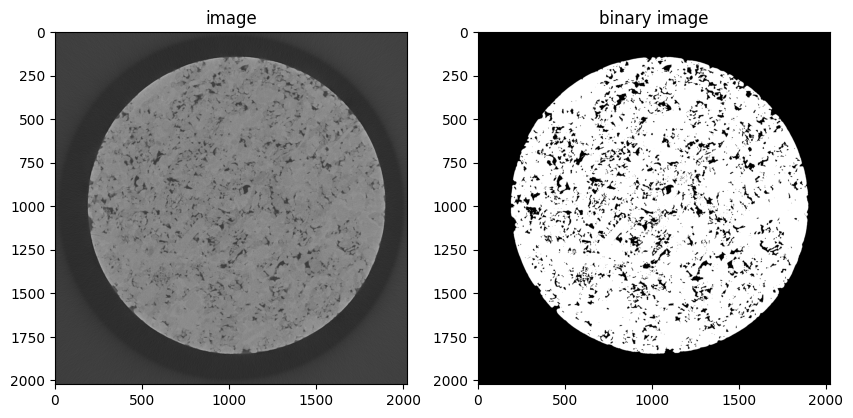

7
7


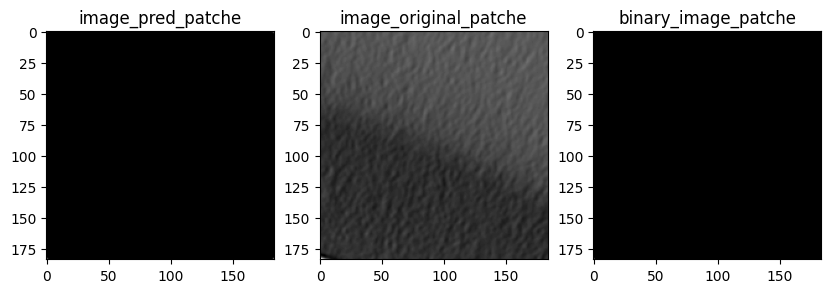

In [29]:
# Create a figure with two subplots+
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Plot the original image
axs[0].imshow(slice_0330_image, cmap='gray')
axs[0].set_title('image')

# Plot the binary image
axs[1].imshow(slice_0330_image_binary, cmap='gray')
axs[1].set_title('binary image')

# Show the plot
plt.show()

## Verificando se as imagens binárias são correspondentes com as imagens de entrada:
import random

# Define the range
min_value = 0
max_value = len(y_pred_slice_0330_tensor)-1 # contando com o zero da um total de 121 slices.

# Generate a random number between the range
random_number = random.randint(min_value, max_value)

# Print the random number
print(random_number)

# Print the random number
print(random_number)
import matplotlib.pyplot as plt
import numpy as np

# Create a figure with two subplots

fig2, axs = plt.subplots(1, 3, figsize=(10, 5))

# Plot the original image
axs[0].imshow(y_pred_slice_0330_tensor[random_number, :, :], cmap='gray')
axs[0].set_title('image_pred_patche')

# Plot the binary image
axs[1].imshow(image_slice_0330_tensor_patches[random_number, :, :], cmap='gray')
axs[1].set_title('image_original_patche')

# Plot the binary image
axs[2].imshow(mask_slice_0330_tensor_patches[random_number, :, :], cmap='gray')
axs[2].set_title('binary_image_patche')

# Show the plot
plt.show()


In [30]:
# Function to reconstruct the original image and mask
def reconstruct_mask(mask_patches_flat, patch_positions_array, image_shape):
    # Get the original image shape
    original_shape = (image_shape[0], image_shape[1])

    # Initialize empty arrays for the reconstructed image and mask
    reconstructed_mask = np.zeros(original_shape, dtype='float32')

    for i, position in enumerate(patch_positions_array):
        start_row, start_col = position['start_row'], position['start_col']
        end_row, end_col = position['end_row'], position['end_col']

        # Extract the patches from the flat arrays
        #image_patch = image_patches_flat[i, :, :, 0]
        mask_patch = mask_patches_flat[i, :, :, 0]

        # Update the reconstructed image and mask
        #reconstructed_image[start_row:end_row, start_col:end_col] = image_patch
        reconstructed_mask[start_row:end_row, start_col:end_col] = mask_patch

    return reconstructed_mask

In [31]:
# Assuming you have image_patches_flat, mask_patches_flat, and patch_positions_array
# (you can replace these with your actual variables)
reconstructed_mask_slice_0330_image_tensor = reconstruct_mask(y_pred_slice_0330_tensor, slice_0330_patch_positions, slice_0330_image.shape)

In [32]:
reconstructed_mask_slice_0330_image_tensor.shape, slice_0330_image_binary.shape

((2024, 2024), (2024, 2024))

In [33]:
reconstructed_mask_slice_0330_image_tensor.min()

4.9034366e-13

In [37]:
slice_0330_image_binary.shape, reconstructed_mask_slice_0330_image_tensor.shape

((2024, 2024), (2024, 2024))

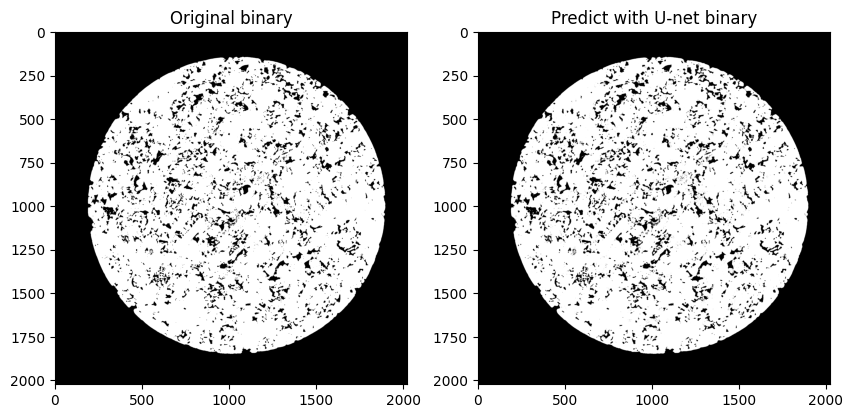

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Create two sample arrays


# Create a figure with two subplots
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

# Plot the original image
axs[0].imshow(slice_0330_image_binary, cmap='gray')
axs[0].set_title('Original binary')

# Plot the binary image
axs[1].imshow(reconstructed_mask_slice_0330_image_tensor, cmap='gray')
axs[1].set_title('Predict with U-net binary')

# Show the plot
plt.show()

In [40]:
from PIL import Image
import numpy as np

# Assuming slice_0330_image_binary and reconstructed_mask_slice_0330_image_tensor are numpy arrays
# Convert tensor images to numpy arrays if they are tensors
slice_0330_image_binary_np = slice_0330_image_binary.numpy()
reconstructed_mask_slice_0330_image_tensor_np = reconstructed_mask_slice_0330_image_tensor.numpy()

# Create PIL Image objects from numpy arrays
slice_0330_image_binary_img = Image.fromarray(slice_0330_image_binary_np)
reconstructed_mask_slice_0330_image_tensor_img = Image.fromarray(reconstructed_mask_slice_0330_image_tensor_np)

# Save images as TIFF files
slice_0330_image_binary_img.save("slice_2200_image_binary_thresold.tiff")
reconstructed_mask_slice_0330_image_tensor_img.save("reconstructed_segmented_slice_2200_cnn.tiff")


AttributeError: 'numpy.ndarray' object has no attribute 'numpy'

In [43]:
from PIL import Image
import numpy as np

reconstructed_mask_slice_0330_image_tensor_img.save("reconstructed_mask_cnn_slice_2529_image_tensor.tiff")


In [77]:
slice_0330_image_binary.min(), reconstructed_mask_slice_0330_image_tensor.max() , reconstructed_mask_slice_0330_image_tensor.min(), reconstructed_mask_slice_0330_image_tensor.max()

(0, 0.99998975, 6.180274e-09, 0.99998975)

In [26]:
# When you set the grain to be the value 1 # background 
# You are suppose to use the calculate_pore_properties_gray_version_rock to calculate the properties
import numpy as np

def calculate_pore_properties_gray_version_rock(segmented_image, pixel_area, circle_area):
    """
    Calculate pore properties including pore area and porosity for a grayscale segmented image.

    Parameters:
    - segmented_image: 2D segmented image where pores are represented by values between 0 and 1.
    - pixel_area: Area of a single pixel in the image.

    Returns:
    - grain_area: Total area of segmented grain regions.
    - fraction_matrix: matrix calculated as the ratio of grain area to the total area.
    """
    # Check if the input image is within the valid range
    if not (np.all(0 <= segmented_image) and np.all(segmented_image <= 1)):
        raise ValueError("Input image must have values between 0 and 1 for grayscale segmentation.")
    # Calculate pore area
    grain_area = np.sum(segmented_image) * pixel_area
    
    # Calculate total area of the image
    #total_area = np.sum(segmented_image >= 0) * pixel_area
    ##total_area = np.sum(segmented_image >= segmented_image.min()) * pixel_area
    total_area = circle_area
    # Calculate porosity
    fraction_matrix = grain_area / total_area
    porosity = 1.0 - fraction_matrix
    pore_area = total_area - grain_area
    return grain_area, fraction_matrix, porosity, pore_area

Circle Area: 2328443.106460623
External Area: 1768132.893539377
Sum of Areas (Internal + External): 4096576.0
Total Area: 4096576
Are the areas equal? True


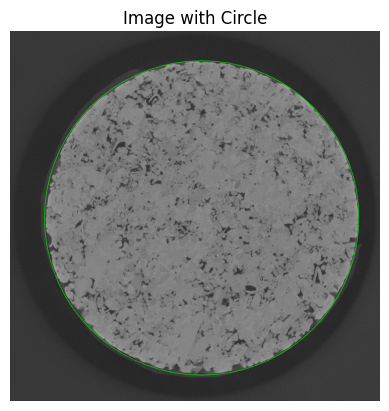

In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('slice0330.tif', cv2.IMREAD_COLOR)

# Get the dimensions of the image
height, width, _ = image.shape

# Calculate the radius and center of the circle (with float coordinates)
circle_radius = min(width, height) / 2.351  # Adjust the radius as needed with a float value
circle_center = (width / 1.93, height / 1.98)  # Float coordinates

# Calculate the area of the circle
circle_area = np.pi * circle_radius ** 2

# Calculate the external area (total area - circle area)
external_area = height * width - circle_area

# Print the calculated areas
print("Circle Area:", circle_area)
print("External Area:", external_area)

# Check if the sum of internal and external areas equals the total area
total_area = height * width
sum_of_areas = circle_area + external_area
print("Sum of Areas (Internal + External):", sum_of_areas)
print("Total Area:", total_area)
print("Are the areas equal?", np.isclose(sum_of_areas, total_area))

# Draw the circle on a copy of the original image
image_with_circle = image.copy()

# Cast the center coordinates and radius to integers before drawing
cv2.circle(image_with_circle, (int(circle_center[0]), int(circle_center[1])), int(circle_radius), (0, 255, 0), 2)

# Plot the original image with the circle
plt.imshow(cv2.cvtColor(image_with_circle, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Image with Circle')

# Show the saved images
plt.show()

In [40]:
# Calculate the variation into the 3121 slices of the tomography image:
# Circle_radius
circle_radius_initial_parameter = 2.351
circle_radius_final_parameter = 2.365
variation_circle_parameter = abs(circle_radius_final_parameter - circle_radius_initial_parameter)
delta_circle_parameter = variation_circle_parameter/3121
delta_circle_parameter, variation_circle_parameter, delta_circle_parameter * 3121

(4.4857417494393575e-06, 0.014000000000000234, 0.014000000000000234)

In [41]:
# calculate the variation into the 3121 width parameter
circle_center_width_initial_parameter = 1.93
circle_center_width_final_parameter = 1.94
variation_center_width_parameter = abs(circle_center_width_final_parameter - circle_center_width_initial_parameter)
delta_center_width_parameter = variation_center_width_parameter/3121
variation_center_width_parameter, delta_center_width_parameter, delta_center_width_parameter * 3121

(0.010000000000000009, 3.2041012495994903e-06, 0.010000000000000009)

In [42]:
# calculate the variation into the 3121 height parameter
circle_center_height_initial_parameter = 1.98
circle_center_height_final_parameter = 2.04
variation_center_height_parameter = abs(circle_center_height_final_parameter - circle_center_height_initial_parameter)
delta_center_height_parameter = variation_center_height_parameter/3121
variation_center_height_parameter, delta_center_height_parameter, delta_center_height_parameter * 3121

(0.06000000000000005, 1.922460749759694e-05, 0.060000000000000046)

Circle Area: 2300957.5095713576
External Area: 1795618.4904286424
Sum of Areas (Internal + External): 4096576.0
Total Area: 4096576
Are the areas equal? True


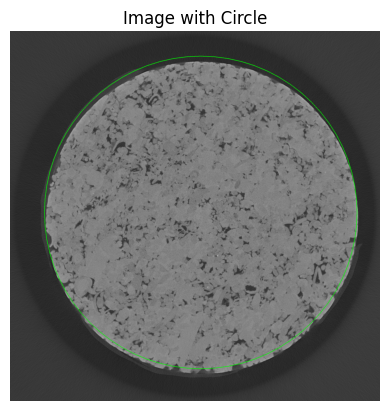

In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('slice0330.tif', cv2.IMREAD_COLOR)

# Get the dimensions of the image
height, width, _ = image.shape

# Calculate the radius and center of the circle (with float coordinates)
circle_radius = min(width, height) / 2.365  # Adjust the radius as needed with a float value
circle_center = (width / 1.94, height / 2.04)  # Float coordinates

# Calculate the area of the circle
circle_area = np.pi * circle_radius ** 2

# Calculate the external area (total area - circle area)
external_area = height * width - circle_area

# Print the calculated areas
print("Circle Area:", circle_area)
print("External Area:", external_area)

# Check if the sum of internal and external areas equals the total area
total_area = height * width
sum_of_areas = circle_area + external_area
print("Sum of Areas (Internal + External):", sum_of_areas)
print("Total Area:", total_area)
print("Are the areas equal?", np.isclose(sum_of_areas, total_area))

# Draw the circle on a copy of the original image
image_with_circle = image.copy()

# Cast the center coordinates and radius to integers before drawing
cv2.circle(image_with_circle, (int(circle_center[0]), int(circle_center[1])), int(circle_radius), (0, 255, 0), 2)

# Plot the original image with the circle
plt.imshow(cv2.cvtColor(image_with_circle, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Image with Circle')

# Show the saved images
plt.show()


## Based on the real size of the object in the world

In [43]:
# In the real world we have 1704 pixels in a diameter with 3.81 cm
value_pixel_real_world=(3.81)/(1704) # Simple rule

In [44]:
# The value in cm of one pixel in real world
print("The value of 1 pixel in real world distance:",value_pixel_real_world,"cm")

# This value is close to the resolution 22 Micrometro

The value of 1 pixel in real world distance: 0.0022359154929577464 cm


In [45]:
# Calculating the distance of the width and height in mm
image_width_cm = (2024 * value_pixel_real_world)
image_height_cm = (2024 * value_pixel_real_world)
print("The value image_width_cm and image_width_cm in real world distance (cm):")
image_width_cm, image_height_cm

The value image_width_cm and image_width_cm in real world distance (cm):


(4.525492957746478, 4.525492957746478)

In [46]:
image_width_m = image_width_cm * (10)**(-2)
image_height_m = image_height_cm * (10)**(-2)
print("The value image_width_m and image_width_m in real world distance (m):")
image_width_m, image_height_m

The value image_width_m and image_width_m in real world distance (m):


(0.045254929577464784, 0.045254929577464784)

In [47]:
# Calculating the total area in meters:
total_check_real_area = (image_width_m) * (image_height_m) 
print("The total area meters in real world:", total_check_real_area,"m^2")

The total area meters in real world: 0.002048008651061297 m^2


In [48]:
# Calculate the total number of pixels in the image
total_pixels_horizontal = 2024
total_pixels_vertical = 2024
total_pixels = total_pixels_horizontal * total_pixels_vertical

# Calculate the area represented by each pixel in the real world
pixel_area_real_world = (image_width_m * image_height_m) / total_pixels

# Print the result
print("Area represented by each pixel in the real world:", pixel_area_real_world, "square meters")

Area represented by each pixel in the real world: 4.999318091648481e-10 square meters


In [49]:
pixel_area = pixel_area_real_world

# Apply the function to calculate the properties:

In [50]:
reconstructed_mask_slice_0330_image_tensor.max(), reconstructed_mask_slice_0330_image_tensor.min()

(0.9999831, 0.0)

In [51]:
reconstructed_mask_slice_0330_image_tensor[reconstructed_mask_slice_0330_image_tensor <= reconstructed_mask_slice_0330_image_tensor.min() ] = 0  

In [52]:
reconstructed_mask_slice_0330_image_tensor.max(), reconstructed_mask_slice_0330_image_tensor.min()

(0.9999831, 0.0)

In [53]:
circle_area_real = circle_area * pixel_area
external_area_real = external_area * pixel_area
#external_area_real, circle_area_real, circle_area_real + external_area_real == Grain_Area_vector_values + pore_Area_vector_values

In [63]:
Grain_Area_vector_values, Grain_fraction_vector_values, porosity_vector_values, pore_Area_vector_values = calculate_pore_properties_gray_version_rock(reconstructed_mask_slice_0330_image_tensor, pixel_area, circle_area_real)

In [60]:
Grain_Area_vector_values, Grain_fraction_vector_values, porosity_vector_values, pore_Area_vector_values = calculate_pore_properties_gray_version_rock(slice_0330_image_binary, pixel_area, circle_area_real)

In [59]:
# para checar após a mudança
Grain_Area_vector_values, Grain_fraction_vector_values, porosity_vector_values, pore_Area_vector_values

(0.0010197272214288147,
 0.8760070707076538,
 0.12399292929234618,
 0.0001443355533214635)

In [61]:
# para checar após a mudança
Grain_Area_vector_values, Grain_fraction_vector_values, porosity_vector_values, pore_Area_vector_values

(0.00099286957231948,
 0.8529347332943246,
 0.14706526670567543,
 0.0001711932024307983)

In [64]:
Grain_Area_vector_values, Grain_fraction_vector_values, porosity_vector_values, pore_Area_vector_values

(0.0010197272214288147,
 0.8760070707076538,
 0.12399292929234618,
 0.0001443355533214635)

In [28]:
# Print the calculated areas
print("Circle Area:", circle_area)
print("External Area:", external_area)

Circle Area: 2328443.106460623
External Area: 1768132.893539377


In [29]:
# check if the sum of grain area and pore area is equal to the circle area
circle_area_real == Grain_Area_vector_values + pore_Area_vector_values

True

## Test the code: to determine each region that are a grain space

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from matplotlib.patches import Rectangle

def outline_regions(binary_image):
    # Rotular cada região conectada na imagem binária
    labeled_image = label(binary_image)

    # Obter propriedades de cada região rotulada
    regions = regionprops(labeled_image)

    # Plot original image
    plt.figure(figsize=(8, 8))
    plt.imshow(binary_image, cmap='gray')

    # Plot contours around each labeled region
    for region in regions:
        # Obter as coordenadas do retângulo envolvente da região
        minr, minc, maxr, maxc = region.bbox
        
        # Ajustar as coordenadas para circundar a região
        minr -= 0.5
        minc -= 0.5
        maxr += 0.5
        maxc += 0.5
        
        rect = Rectangle((minc, minr), maxc - minc, maxr - minr, fill=False, edgecolor='red', linewidth=2)
        plt.gca().add_patch(rect)

    plt.axis('image')
    plt.show()


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from matplotlib.patches import Rectangle

def outline_regions(binary_image):
    # Inverter a imagem binária para rotular os componentes conectados das regiões com valor zero
    inverted_image = 1 - binary_image

    # Rotular cada região conectada na imagem binária invertida
    labeled_image = label(inverted_image)

    # Obter propriedades de cada região rotulada
    regions = regionprops(labeled_image)

    # Plot original image
    plt.figure(figsize=(8, 8))
    plt.imshow(binary_image, cmap='gray')

    # Plot contours around each labeled region
    for region in regions:
        # Obter as coordenadas do retângulo envolvente da região
        minr, minc, maxr, maxc = region.bbox

        # Ajustar as coordenadas para circundar a região
        minr -= 0.5
        minc -= 0.5
        maxr += 0.5
        maxc += 0.5

        rect = Rectangle((minc, minr), maxc - minc, maxr - minr, fill=False, edgecolor='red', linewidth=2)
        plt.gca().add_patch(rect)

    plt.axis('image')
    plt.show()

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from matplotlib.patches import Circle

def outline_regions(binary_image):
    # Inverter a imagem binária para rotular os componentes conectados das regiões com valor zero
    inverted_image = 1 - binary_image

    # Rotular cada região conectada na imagem binária invertida
    labeled_image = label(inverted_image)

    # Obter propriedades de cada região rotulada
    regions = regionprops(labeled_image)

    # Plot original image
    plt.figure(figsize=(8, 8))
    plt.imshow(binary_image, cmap='gray')

    # Plot circles around each labeled region
    for region in regions:
        # Calcular o centro da região
        centroid_row, centroid_col = region.centroid
        
        # Calcular o raio do círculo
        radius = max((region.bbox[2] - region.bbox[0]) / 2, (region.bbox[3] - region.bbox[1]) / 2)
        
        # Desenhar o círculo
        circle = Circle((centroid_col, centroid_row), radius, fill=False, edgecolor='red', linewidth=2)
        plt.gca().add_patch(circle)

    plt.axis('image')
    plt.show()



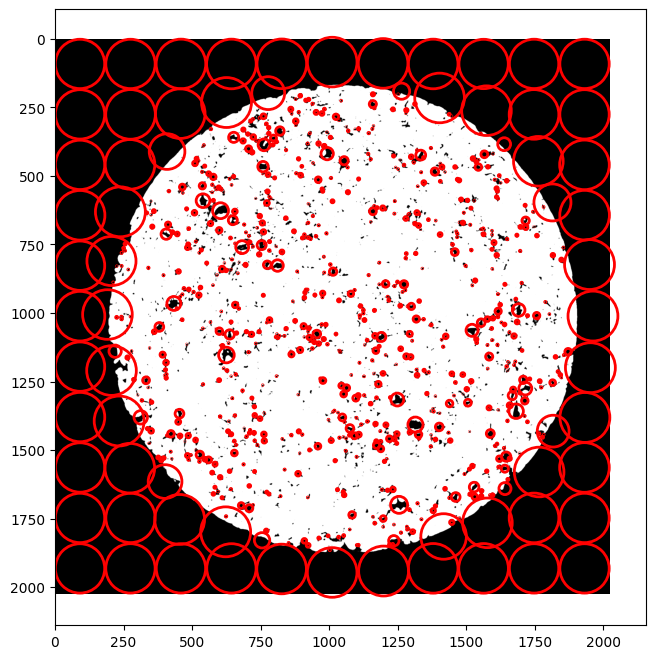

In [40]:
outline_regions(reconstructed_mask_slice_0330_image_tensor)